In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.metrics import auc, roc_curve, precision_recall_curve, average_precision_score


def find_repo_root() -> Path:
    here = Path.cwd().resolve()
    for _ in range(5):
        if (here / "hpc").exists():
            return here
        here = here.parent
    return Path.cwd().resolve()


ROOT = find_repo_root()
BEFORE_CSV = ROOT / "hpc/before_finetuning_results_full.csv"
FINETUNED_CSV = ROOT / "hpc/finetuned_results_3epochs.csv"

before_df_raw = pd.read_csv(BEFORE_CSV, sep=";")
finetuned_df_raw = pd.read_csv(FINETUNED_CSV, sep=";")

print("ROOT:", ROOT)
print("before:", before_df_raw.shape)
print("finetuned:", finetuned_df_raw.shape)


def _to01(series: pd.Series) -> pd.Series:
    if series.dtype == bool:
        return series.fillna(False).astype(int)
    s = series.fillna(False).astype(str).str.strip().str.lower()
    trueish = s.isin(["true", "1", "yes", "y", "t"])
    falseish = s.isin(["false", "0", "no", "n", "f", "nan", "none", ""])
    out = pd.Series(np.where(trueish, 1, np.where(falseish, 0, 0)), index=series.index)
    return out.astype(int)


def normalize_frame(frame: pd.DataFrame) -> pd.DataFrame:
    df = frame.copy()

    for col in ["dataset", "categorie", "subcategorie"]:
        if col not in df.columns:
            raise KeyError(f"Missing required column: {col}")
        df[col] = df[col].fillna("NA").astype(str)

    for col in ["first_try_correct", "second_try_correct"]:
        if col in df.columns:
            df[col] = _to01(df[col])
        else:
            df[col] = 0

    for metric in ["max_prob", "entropy", "margin", "verbal"]:
        for try_name in ["first", "second"]:
            col = f"{try_name}_try_{metric}"
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors="coerce")

    return df


before_df = normalize_frame(before_df_raw)
finetuned_df = normalize_frame(finetuned_df_raw)


def single_answer_mask(df: pd.DataFrame) -> pd.Series:
    return (~df["dataset"].str.contains("maqa", case=False, na=False)) | (df["dataset"].str.contains("single", case=False, na=False))


before_single = before_df[single_answer_mask(before_df)].copy()
finetuned_single = finetuned_df[single_answer_mask(finetuned_df)].copy()

print("before single:", before_single.shape)
print("finetuned single:", finetuned_single.shape)

ROOT: /home/oskar/school/transformers/tf_project
before: (25455, 19)
finetuned: (24889, 19)
before single: (15979, 19)
finetuned single: (15418, 19)


/tmp/ipykernel_23212/2548813166.py:33: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  s = series.fillna(False).astype(str).str.strip().str.lower()
/tmp/ipykernel_23212/2548813166.py:33: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  s = series.fillna(False).astype(str).str.strip().str.lower()


In [25]:
METRICS = ["max_prob", "entropy", "margin", "verbal"]
METRIC_COLORS = {
    "max_prob": "tab:blue",
    "entropy": "tab:orange",
    "margin": "tab:green",
    "verbal": "tab:red",
}
METRIC_LABELS = {
    "max_prob": "max prob",
    "entropy": "entropy",
    "margin": "margin",
    "verbal": "verbal",
}


def _score_col(try_name: str, metric: str) -> str:
    return f"{try_name}_try_{metric}"


def _label_col(try_name: str) -> str:
    return f"{try_name}_try_correct"


def _coerce_numeric(series: pd.Series) -> np.ndarray:
    return pd.to_numeric(series, errors="coerce").astype(float).to_numpy()


def _invert_scores(scores: np.ndarray) -> np.ndarray:
    scores = scores.astype(float)
    finite = np.isfinite(scores)
    if not finite.any():
        return scores
    max_val = float(np.nanmax(scores[finite]))
    scale = 1.0 if max_val <= 1.0 else 100.0
    return scale - scores


def compute_roc(y_true: np.ndarray, scores: np.ndarray) -> tuple[np.ndarray, np.ndarray, float] | None:
    mask = np.isfinite(scores)
    y = y_true[mask]
    s = scores[mask]
    if y.size == 0 or np.unique(y).size < 2:
        return None
    fpr, tpr, _ = roc_curve(y, s)
    return fpr, tpr, float(auc(fpr, tpr))


def compute_pr(y_true: np.ndarray, scores: np.ndarray) -> tuple[np.ndarray, np.ndarray, float] | None:
    mask = np.isfinite(scores)
    y = y_true[mask]
    s = scores[mask]
    if y.size == 0 or y.sum() == 0:
        return None
    precision, recall, _ = precision_recall_curve(y, s)
    ap = float(average_precision_score(y, s))
    return recall, precision, ap


def iter_groups(frame: pd.DataFrame):
    keys = ("dataset", "categorie", "subcategorie")
    for (dataset, categorie, subcategorie), g in frame.groupby(list(keys), dropna=False):
        yield (str(dataset), str(categorie), str(subcategorie)), g.copy()


def _pad_curve_to_unit_interval(x: np.ndarray, y: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    if x.size == 0:
        return x, y
    if x[0] > 0:
        x = np.concatenate([[0.0], x])
        y = np.concatenate([[y[0]], y])
    if x[-1] < 1:
        x = np.concatenate([x, [1.0]])
        y = np.concatenate([y, [y[-1]]])
    return x, y


def average_roc_curves(
    frame: pd.DataFrame,
    *,
    choose_by_plain_threshold: float = 0.5,
    fpr_grid: np.ndarray | None = None,
 ) -> dict[tuple[str, str], tuple[np.ndarray, np.ndarray, float, bool]]:
    """Return one ROC curve per (try_name, metric).
    If plain AUROC < threshold, plot the inverted-score ROC instead (when available).
    """
    if fpr_grid is None:
        fpr_grid = np.linspace(0.0, 1.0, 201)

    def _mean_roc_for(try_name: str, metric: str, *, inverted: bool) -> tuple[np.ndarray, float] | None:
        tprs: list[np.ndarray] = []
        for (_key, g) in iter_groups(frame):
            lbl_col = _label_col(try_name)
            sc_col = _score_col(try_name, metric)
            if lbl_col not in g.columns or sc_col not in g.columns:
                continue
            y_true = g[lbl_col].to_numpy(dtype=int)
            scores = _coerce_numeric(g[sc_col])
            if inverted:
                scores = _invert_scores(scores)
            roc_res = compute_roc(y_true, scores)
            if roc_res is None:
                continue
            fpr, tpr, _ = roc_res
            fpr, tpr = _pad_curve_to_unit_interval(fpr, tpr)
            tprs.append(np.interp(fpr_grid, fpr, tpr))
        if not tprs:
            return None
        mean_tpr = np.mean(np.vstack(tprs), axis=0)
        return mean_tpr, float(auc(fpr_grid, mean_tpr))

    out: dict[tuple[str, str], tuple[np.ndarray, np.ndarray, float, bool]] = {}
    for try_name in ["first", "second"]:
        for metric in METRICS:
            plain = _mean_roc_for(try_name, metric, inverted=False)
            if plain is None:
                continue
            mean_tpr_plain, auc_plain = plain
            want_invert = auc_plain < choose_by_plain_threshold
            if want_invert:
                inv = _mean_roc_for(try_name, metric, inverted=True)
                if inv is not None:
                    mean_tpr_inv, auc_inv = inv
                    out[(try_name, metric)] = (fpr_grid, mean_tpr_inv, float(auc_inv), True)
                    continue
            out[(try_name, metric)] = (fpr_grid, mean_tpr_plain, float(auc_plain), False)
    return out


def average_pr_curves(
    frame: pd.DataFrame,
    *,
    orientation: dict[tuple[str, str], bool] | None = None,
    recall_grid: np.ndarray | None = None,
 ) -> dict[tuple[str, str], tuple[np.ndarray, np.ndarray, float, bool]]:
    """Return one PR curve per (try_name, metric), matching a given ROC-based orientation."""
    if recall_grid is None:
        recall_grid = np.linspace(0.0, 1.0, 201)
    if orientation is None:
        roc_curves = average_roc_curves(frame)
        orientation = {k: inv for k, (_x, _y, _auc, inv) in roc_curves.items()}

    def _mean_pr_for(try_name: str, metric: str, *, inverted: bool) -> tuple[np.ndarray, float] | None:
        precs: list[np.ndarray] = []
        aps: list[float] = []
        for (_key, g) in iter_groups(frame):
            lbl_col = _label_col(try_name)
            sc_col = _score_col(try_name, metric)
            if lbl_col not in g.columns or sc_col not in g.columns:
                continue
            y_true = g[lbl_col].to_numpy(dtype=int)
            scores = _coerce_numeric(g[sc_col])
            if inverted:
                scores = _invert_scores(scores)
            pr_res = compute_pr(y_true, scores)
            if pr_res is None:
                continue
            recall, precision, ap = pr_res
            recall = recall[::-1]
            precision = precision[::-1]
            recall, precision = _pad_curve_to_unit_interval(recall, precision)
            precs.append(np.interp(recall_grid, recall, precision))
            aps.append(float(ap))
        if not precs:
            return None
        mean_prec = np.mean(np.vstack(precs), axis=0)
        mean_ap = float(np.mean(aps)) if aps else float("nan")
        return mean_prec, mean_ap

    out: dict[tuple[str, str], tuple[np.ndarray, np.ndarray, float, bool]] = {}
    for try_name in ["first", "second"]:
        for metric in METRICS:
            inv = bool(orientation.get((try_name, metric), False))
            mean_prec = _mean_pr_for(try_name, metric, inverted=inv)
            if mean_prec is None and inv:
                mean_prec = _mean_pr_for(try_name, metric, inverted=False)
                inv = False
            if mean_prec is None:
                continue
            prec, ap = mean_prec
            out[(try_name, metric)] = (recall_grid, prec, float(ap), inv)
    return out


def average_pr_baseline(frame: pd.DataFrame) -> float:
    rates = []
    for (_key, g) in iter_groups(frame):
        if "first_try_correct" in g.columns:
            rates.append(float(g["first_try_correct"].mean()))
    return float(np.mean(rates)) if rates else 0.0


def _second_try_gain(frame: pd.DataFrame) -> np.ndarray:
    first = frame["first_try_correct"].to_numpy(dtype=int)
    second = frame["second_try_correct"].to_numpy(dtype=int)
    return ((first == 0) & (second == 1)).astype(int)

In [26]:
def plot_average_panels_compare(
    before_all: pd.DataFrame,
    before_single: pd.DataFrame,
    finetuned_all: pd.DataFrame,
    finetuned_single: pd.DataFrame,
    *,
    before_label: str = "before",
    finetuned_label: str = "finetuned",
    before_alpha: float = 0.45,
    finetuned_alpha: float = 1.0,
    fig_title_suffix: str = "(before vs finetuned)",
) -> None:
    dotted_inv = ":"
    dotted_plain_thick = (0, (1, 6))
    lw_first = 1.8
    lw_second = 2.2
    
    # Font settings
    TITLE_SIZE = 16
    AXIS_LABEL_SIZE = 14
    TICK_LABEL_SIZE = 12
    LEGEND_SIZE = 14  # Increased legend size
    LEGEND_SPACING = 1.1 # Increased legend label spacing

    def _style_square(ax):
        ax.set_aspect("equal", adjustable="box")
        ax.grid(True, alpha=0.25)
        ax.tick_params(axis='both', which='major', labelsize=TICK_LABEL_SIZE)

    def _ls_and_lw(try_name: str, inverted: bool) -> tuple[object, float]:
        if try_name == "first":
            return (dotted_inv if inverted else "-"), lw_first
        return (dotted_inv if inverted else dotted_plain_thick), lw_second

    def _plot_roc(ax, frame_before, frame_ft, title):
        curves_before = average_roc_curves(frame_before)
        curves_ft = average_roc_curves(frame_ft)
        ax.plot([0, 1], [0, 1], "k--", lw=1.0, label="always predict correct")

        for metric in METRICS:
            color = METRIC_COLORS[metric]
            metric_label = METRIC_LABELS.get(metric, metric)
            for try_name in ["first", "second"]:
                key = (try_name, metric)
                if key in curves_before:
                    x, y, a_, inv = curves_before[key]
                    ls, lw = _ls_and_lw(try_name, inv)
                    inv_tag = " (inverted)" if inv else ""
                    ax.plot(
                        x,
                        y,
                        linestyle=ls,
                        color=color,
                        lw=lw,
                        alpha=before_alpha,
                        label=f"{metric_label} ({try_name}{inv_tag}, AUC={a_:.2f}) [{before_label}]",
                    )
                if key in curves_ft:
                    x, y, a_, inv = curves_ft[key]
                    ls, lw = _ls_and_lw(try_name, inv)
                    inv_tag = " (inverted)" if inv else ""
                    ax.plot(
                        x,
                        y,
                        linestyle=ls,
                        color=color,
                        lw=lw,
                        alpha=finetuned_alpha,
                        label=f"{metric_label} ({try_name}{inv_tag}, AUC={a_:.2f}) [{finetuned_label}]",
                    )

        ax.set_title(title, fontsize=TITLE_SIZE)
        ax.set_xlabel("False Positive Rate", fontsize=AXIS_LABEL_SIZE)
        ax.set_ylabel("True Positive Rate", fontsize=AXIS_LABEL_SIZE)
        _style_square(ax)

    def _plot_pr(ax, frame_before, frame_ft, title):
        roc_before = average_roc_curves(frame_before)
        roc_ft = average_roc_curves(frame_ft)
        orient_before = {k: inv for k, (_x, _y, _auc, inv) in roc_before.items()}
        orient_ft = {k: inv for k, (_x, _y, _auc, inv) in roc_ft.items()}
        curves_before = average_pr_curves(frame_before, orientation=orient_before)
        curves_ft = average_pr_curves(frame_ft, orientation=orient_ft)

        base_before = average_pr_baseline(frame_before)
        base_ft = average_pr_baseline(frame_ft)
        ax.plot(
            [0, 1],
            [base_before, base_before],
            "k--",
            lw=1.0,
            alpha=before_alpha,
            label=f"random (p={base_before:.2f}) [{before_label}]",
        )
        ax.plot(
            [0, 1],
            [base_ft, base_ft],
            "k--",
            lw=1.0,
            alpha=finetuned_alpha,
            label=f"random (p={base_ft:.2f}) [{finetuned_label}]",
        )

        for metric in METRICS:
            color = METRIC_COLORS[metric]
            metric_label = METRIC_LABELS.get(metric, metric)
            for try_name in ["first", "second"]:
                key = (try_name, metric)
                if key in curves_before:
                    x, y, ap, inv = curves_before[key]
                    ls, lw = _ls_and_lw(try_name, inv)
                    inv_tag = " (inverted)" if inv else ""
                    ax.plot(
                        x,
                        y,
                        linestyle=ls,
                        color=color,
                        lw=lw,
                        alpha=before_alpha,
                        label=f"{metric_label} ({try_name}{inv_tag}, AP={ap:.2f}) [{before_label}]",
                    )
                if key in curves_ft:
                    x, y, ap, inv = curves_ft[key]
                    ls, lw = _ls_and_lw(try_name, inv)
                    inv_tag = " (inverted)" if inv else ""
                    ax.plot(
                        x,
                        y,
                        linestyle=ls,
                        color=color,
                        lw=lw,
                        alpha=finetuned_alpha,
                        label=f"{metric_label} ({try_name}{inv_tag}, AP={ap:.2f}) [{finetuned_label}]",
                    )

        ax.set_title(title, fontsize=TITLE_SIZE)
        ax.set_xlabel("Recall", fontsize=AXIS_LABEL_SIZE)
        ax.set_ylabel("Precision", fontsize=AXIS_LABEL_SIZE)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1.05)
        _style_square(ax)

    def _plot_pair_separate(frame_before, frame_ft, *, title_prefix: str, file_tag: str):
        # 1. ROC Plot
        fig_roc, ax_roc = plt.subplots(figsize=(10, 8)) # Adjusted height slightly
        roc_title = f"{title_prefix} ROC for the First and the Second try{fig_title_suffix}"
        _plot_roc(ax_roc, frame_before, frame_ft, roc_title)
        
        # Move legend to the right
        ax_roc.legend(
            loc="upper left",
            bbox_to_anchor=(1.02, 1),
            borderaxespad=0,
            fontsize=LEGEND_SIZE,
            frameon=False,
            labelspacing=LEGEND_SPACING
        )
        # Save ROC
        clean_tag = file_tag.replace(" ", "_").lower().strip("_")
        save_path_roc = f"roc_curve_{clean_tag}.png"
        plt.savefig(save_path_roc, dpi=900, bbox_inches="tight")
        print(f"Saved {save_path_roc}")
        plt.show()

        # 2. PR Plot
        fig_pr, ax_pr = plt.subplots(figsize=(10, 8)) # Adjusted height slightly
        pr_title = f"{title_prefix} PR for the First and the Second try{fig_title_suffix}"
        _plot_pr(ax_pr, frame_before, frame_ft, pr_title)
        
        # Move legend to the right
        ax_pr.legend(
            loc="upper left",
            bbox_to_anchor=(1.02, 1),
            borderaxespad=0,
            fontsize=LEGEND_SIZE,
            frameon=False,
            labelspacing=LEGEND_SPACING
        )
        
        # Save PR
        save_path_pr = f"pr_curve_{clean_tag}.png"
        plt.savefig(save_path_pr, dpi=900, bbox_inches="tight")
        print(f"Saved {save_path_pr}")
        plt.show()

    _plot_pair_separate(before_all, finetuned_all, title_prefix="Average (all groups)", file_tag="all_groups")
    _plot_pair_separate(before_single, finetuned_single, title_prefix="Average (single-answer subset)", file_tag="single_answer")

PR Curves (No Inversion) - All Groups


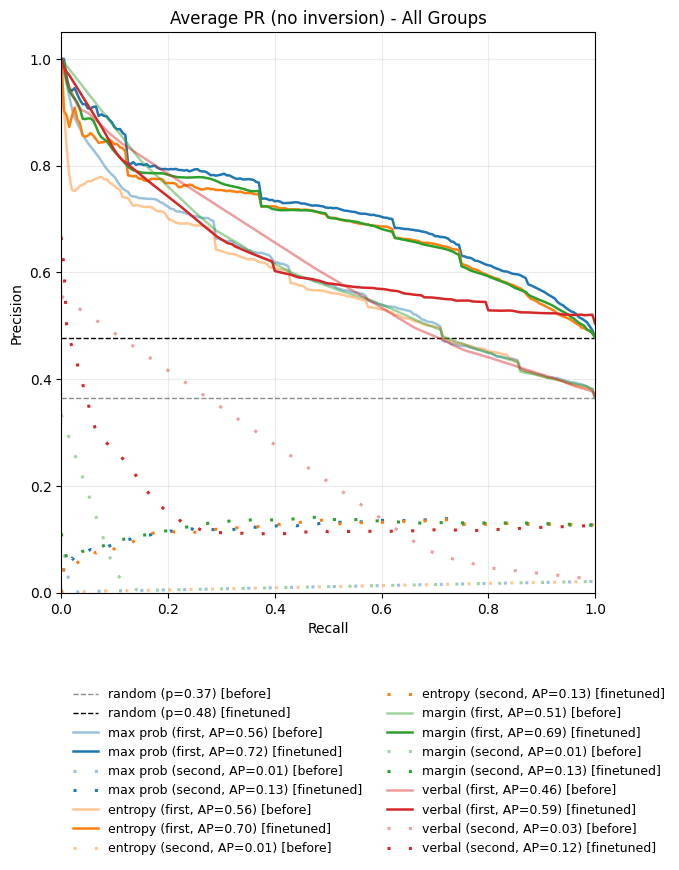

PR Curves (No Inversion) - Single-Answer Subset


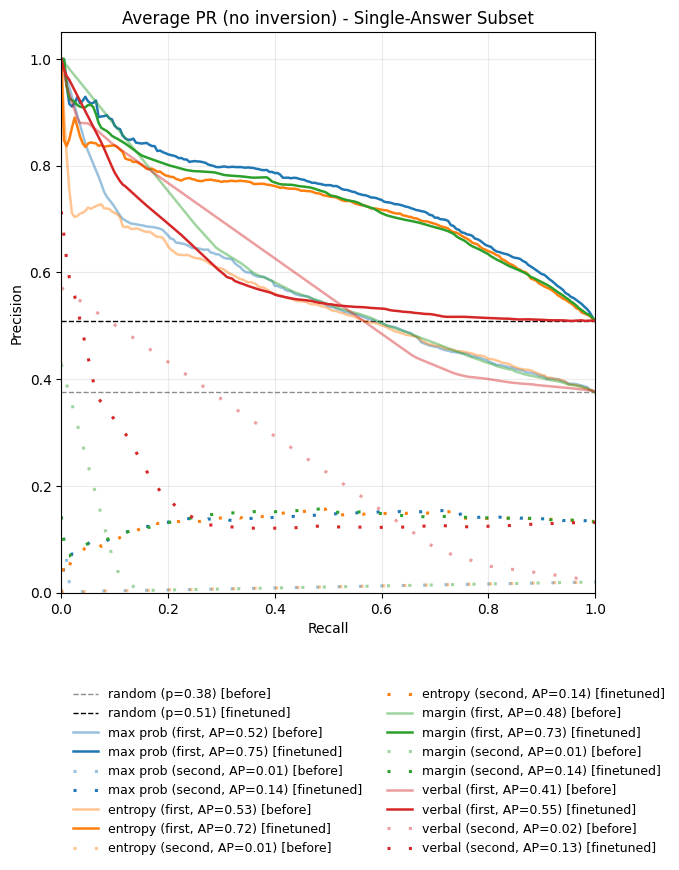

In [27]:
def plot_pr_no_inversion(
    before_frame: pd.DataFrame,
    finetuned_frame: pd.DataFrame,
    title: str,
    before_alpha: float = 0.45,
    finetuned_alpha: float = 1.0,
    before_label: str = "before",
    finetuned_label: str = "finetuned",
):
    # Force no inversion for all keys
    force_no_inv = {}
    for try_name in ["first", "second"]:
        for metric in METRICS:
            force_no_inv[(try_name, metric)] = False

    curves_before = average_pr_curves(before_frame, orientation=force_no_inv)
    curves_ft = average_pr_curves(finetuned_frame, orientation=force_no_inv)

    base_before = average_pr_baseline(before_frame)
    base_ft = average_pr_baseline(finetuned_frame)

    fig, ax = plt.subplots(figsize=(9, 9))
    
    ax.plot(
        [0, 1],
        [base_before, base_before],
        "k--",
        lw=1.0,
        alpha=before_alpha,
        label=f"random (p={base_before:.2f}) [{before_label}]",
    )
    ax.plot(
        [0, 1],
        [base_ft, base_ft],
        "k--",
        lw=1.0,
        alpha=finetuned_alpha,
        label=f"random (p={base_ft:.2f}) [{finetuned_label}]",
    )

    dotted_plain_thick = (0, (1, 6))
    lw_first = 1.8
    lw_second = 2.2

    for metric in METRICS:
        color = METRIC_COLORS[metric]
        metric_label = METRIC_LABELS.get(metric, metric)
        for try_name in ["first", "second"]:
            key = (try_name, metric)
            
            # Helper to add plot
            def add_line(frame_curves, alpha, label_suffix):
                 if key in frame_curves:
                    x, y, ap, _ = frame_curves[key]
                    ls = "-" if try_name == "first" else dotted_plain_thick
                    ax.plot(
                        x, y, 
                        linestyle=ls, color=color, lw=(lw_first if try_name == "first" else lw_second),
                        alpha=alpha,
                        label=f"{metric_label} ({try_name}, AP={ap:.2f}) [{label_suffix}]"
                    )

            add_line(curves_before, before_alpha, before_label)
            add_line(curves_ft, finetuned_alpha, finetuned_label)

    ax.set_title(title)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.05)
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.25)
    
    ax.legend(
        loc="upper left",
        bbox_to_anchor=(0.0, -0.15),
        ncol=2,
        fontsize=9,
        frameon=False,
    )
    plt.tight_layout()
    plt.show()

print("PR Curves (No Inversion) - All Groups")
plot_pr_no_inversion(before_df, finetuned_df, title="Average PR (no inversion) - All Groups")

print("PR Curves (No Inversion) - Single-Answer Subset")
plot_pr_no_inversion(before_single, finetuned_single, title="Average PR (no inversion) - Single-Answer Subset")

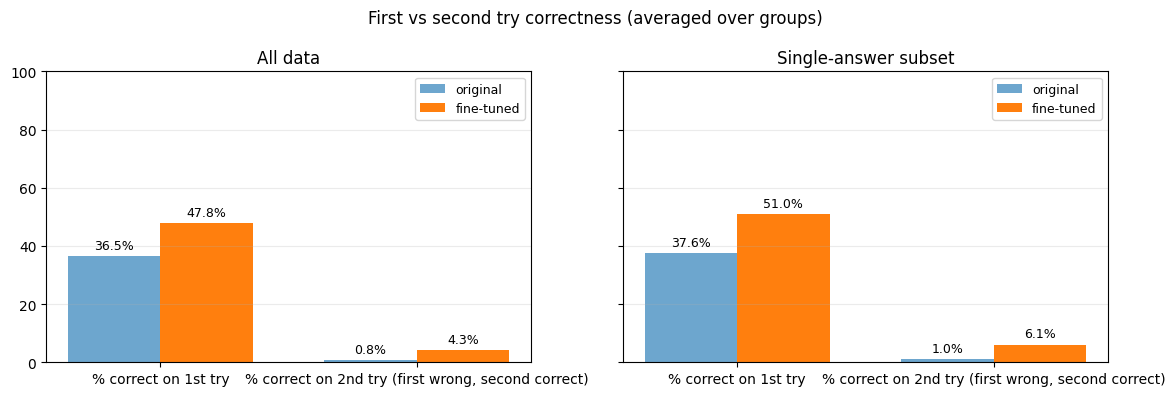

,dataset,categorie,subcategorie,n_before,first_rate_before,second_rate_before,n_finetuned,first_rate_finetuned,second_rate_finetuned,first_rate_delta,second_rate_delta
0,gsm8k_test,math,NA,1319,0.166035,0.007582,1238,0.274637,0.109047,0.108602,0.101465
1,gsm8k_train,math,NA,7473,0.174093,0.015523,7073,0.331684,0.097554,0.157590,0.082032
2,maqa_commonsense_reasoning,commonsense single,NA,8434,0.632203,0.014228,8430,0.815184,0.029537,0.182981,0.015309
3,maqa_mathematical_reasoning,math,multi,400,0.387500,0.007500,399,0.458647,0.020050,0.071147,0.012550
4,maqa_single_commonsense_reasoning,commonsense single,NA,2290,0.638865,0.012227,2290,0.806987,0.031004,0.168122,0.018777
5,maqa_single_math_reasoning,math,single,1319,0.165277,0.010614,1241,0.282836,0.119259,0.117560,0.108645
6,maqa_single_world_knowledge_nq,world knowledge,single NQ,1288,0.214286,0.002329,1288,0.278727,0.014752,0.064441,0.012422
7,maqa_world_knowledge_hls,world knowledge,multi HLS,50,0.140000,0.000000,50,0.160000,0.000000,0.020000,0.000000
8,maqa_world_knowledge_nq,world knowledge,multi NQ,592,0.228041,0.000000,592,0.256757,0.000000,0.028716,0.000000
9,strategyqa_dev,NA,NA,229,0.628821,0.008734,229,0.794760,0.017467,0.165939,0.008734


In [28]:
def rates_by_group(frame: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for (dataset, categorie, subcategorie), g in iter_groups(frame):
        first_rate = float(g["first_try_correct"].mean()) if len(g) else 0.0
        second_rate = float(_second_try_gain(g).mean()) if len(g) else 0.0
        rows.append({
            "dataset": dataset,
            "categorie": categorie,
            "subcategorie": subcategorie,
            "n": int(len(g)),
            "first_rate": first_rate,
            "second_rate": second_rate,
        })
    out = pd.DataFrame(rows)
    return out.sort_values(["dataset", "categorie", "subcategorie"]).reset_index(drop=True)


def plot_first_vs_second_rates_compare(
    before_all: pd.DataFrame,
    before_single: pd.DataFrame,
    finetuned_all: pd.DataFrame,
    finetuned_single: pd.DataFrame,
    *,
    before_label: str = "original",
    finetuned_label: str = "fine-tuned",
) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
    for ax, (title, b_frame, f_frame) in zip(
        axes,
        [
            ("All data", before_all, finetuned_all),
            ("Single-answer subset", before_single, finetuned_single),
        ],
    ):
        # Multiply by 100 to convert to percentage (0-100 range)
        b = rates_by_group(b_frame)[["first_rate", "second_rate"]].mean() * 100
        f = rates_by_group(f_frame)[["first_rate", "second_rate"]].mean() * 100

        x = np.arange(2)
        w = 0.36
        rects_b = ax.bar(x - w / 2, [b["first_rate"], b["second_rate"]], width=w, label=before_label, alpha=0.65)
        rects_f = ax.bar(x + w / 2, [f["first_rate"], f["second_rate"]], width=w, label=finetuned_label, alpha=1.0)
        
        # Use {:.1f}% because values are already 0-100
        ax.bar_label(rects_b, fmt='{:.1f}%', padding=3, fontsize=9)
        ax.bar_label(rects_f, fmt='{:.1f}%', padding=3, fontsize=9)
        
        ax.set_xticks(x)
        ax.set_xticklabels([
            "% correct on 1st try",
            "% correct on 2nd try (first wrong, second correct)",
        ])
        ax.set_title(title)
        ax.set_ylim(0, 100)
        ax.grid(True, axis="y", alpha=0.25)
        ax.legend(fontsize=9)
    fig.suptitle("First vs second try correctness (averaged over groups)")
    plt.tight_layout()
    plt.show()


plot_first_vs_second_rates_compare(before_df, before_single, finetuned_df, finetuned_single)


# Per-group comparison table (before vs finetuned)
before_group_all = rates_by_group(before_df).rename(
    columns={
        "first_rate": "first_rate_before",
        "second_rate": "second_rate_before",
        "n": "n_before",
    }
)
finetuned_group_all = rates_by_group(finetuned_df).rename(
    columns={
        "first_rate": "first_rate_finetuned",
        "second_rate": "second_rate_finetuned",
        "n": "n_finetuned",
    }
)

group_cmp_all = before_group_all.merge(
    finetuned_group_all,
    on=["dataset", "categorie", "subcategorie"],
    how="outer",
)
group_cmp_all["first_rate_delta"] = group_cmp_all["first_rate_finetuned"] - group_cmp_all["first_rate_before"]
group_cmp_all["second_rate_delta"] = group_cmp_all["second_rate_finetuned"] - group_cmp_all["second_rate_before"]

group_cmp_all.sort_values(["dataset", "categorie", "subcategorie"]).head(20)

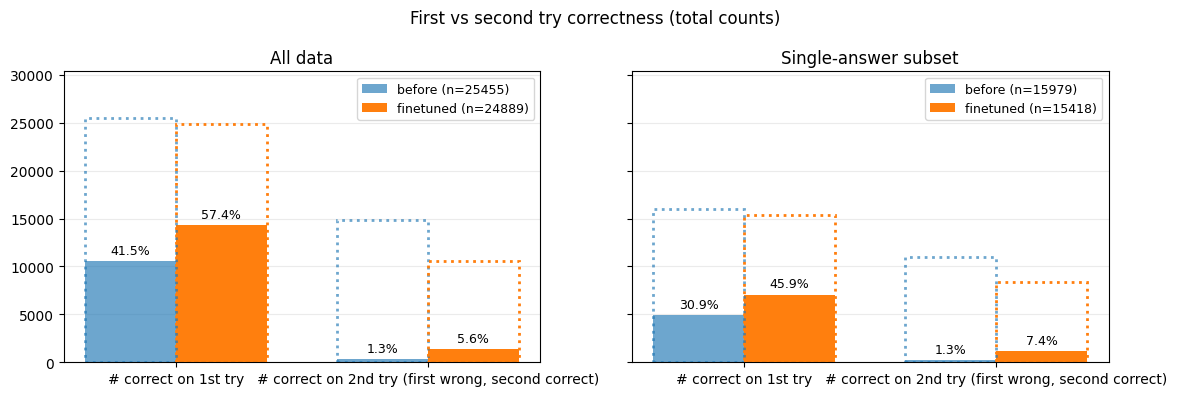

In [29]:
def total_counts(frame: pd.DataFrame) -> dict[str, int]:
    n = int(len(frame))
    first_correct = int(frame["first_try_correct"].sum()) if n else 0
    second_gain = int(_second_try_gain(frame).sum()) if n else 0
    # Count questions that got a second try (where first try was wrong)
    n_second_try = int((frame["first_try_correct"] == 0).sum()) if n else 0
    return {"n": n, "first_correct": first_correct, "second_gain": second_gain, "n_second_try": n_second_try}


def plot_first_vs_second_counts_compare(
    before_all: pd.DataFrame,
    before_single: pd.DataFrame,
    finetuned_all: pd.DataFrame,
    finetuned_single: pd.DataFrame,
    *,
    before_label: str = "before",
    finetuned_label: str = "finetuned",
) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
    for ax, (title, b_frame, f_frame) in zip(
        axes,
        [
            ("All data", before_all, finetuned_all),
            ("Single-answer subset", before_single, finetuned_single),
        ],
    ):
        b = total_counts(b_frame)
        f = total_counts(f_frame)

        x = np.arange(2)
        w = 0.36
        before_bars = ax.bar(
            x - w / 2,
            [b["first_correct"], b["second_gain"]],
            width=w,
            label=f"{before_label} (n={b['n']})",
            alpha=0.65,
            zorder=2,
        )
        finetuned_bars = ax.bar(
            x + w / 2,
            [f["first_correct"], f["second_gain"]],
            width=w,
            label=f"{finetuned_label} (n={f['n']})",
            alpha=1.0,
            zorder=2,
        )

        before_color = before_bars.patches[0].get_facecolor() if before_bars.patches else "C0"
        finetuned_color = finetuned_bars.patches[0].get_facecolor() if finetuned_bars.patches else "C1"

        # Total questions overlays: empty bars with dotted outlines, same color as each series
        # For first try: show total n
        # For second try: show only questions that got a second try (where first was wrong)
        ax.bar(
            x - w / 2,
            [b["n"], b["n_second_try"]],
            width=w,
            facecolor="none",
            edgecolor=before_color,
            linewidth=2.0,
            linestyle=":",
            zorder=3,
        )
        ax.bar(
            x + w / 2,
            [f["n"], f["n_second_try"]],
            width=w,
            facecolor="none",
            edgecolor=finetuned_color,
            linewidth=2.0,
            linestyle=":",
            zorder=3,
        )
        
        # Add values (percentages of total)
        for bars, d in [(before_bars, b), (finetuned_bars, f)]:
            n = d["n"]
            if n > 0:
                labels = [
                    f"{d['first_correct']/n:.1%}",
                    f"{d['second_gain']/n:.1%}"
                ]
                ax.bar_label(bars, labels=labels, padding=3, fontsize=9)


        ax.set_xticks(x)
        ax.set_xticklabels([
            "# correct on 1st try",
            "# correct on 2nd try (first wrong, second correct)",
        ])
        ax.set_title(title)
        ax.grid(True, axis="y", alpha=0.25, zorder=0)
        ax.legend(fontsize=9)

        ymax = max(b["n"], f["n"], 1)
        ax.set_ylim(0, ymax * 1.9)

    fig.suptitle("First vs second try correctness (total counts)")
    plt.tight_layout()
    plt.show()


plot_first_vs_second_counts_compare(before_df, before_single, finetuned_df, finetuned_single)

# Plot of maximum probability method

This plot shows the results for the maximum probability method. On the x-axis is the average probability of all output tokens and on the y-axis is the amount of question whose answer had this propability. The probabilities are between 0 and 100, with precision of two places after decimal point. I need you to average the probabilities to the integers like 94, 95 and so on. On the same graph, show the points for both correctly predicted answers and for wronglt predicted. Make the graph in histogram format. Make the correct answers blue, the wrong answers red, but with trasparency of 0.5 so that when they overlap, both are seen.

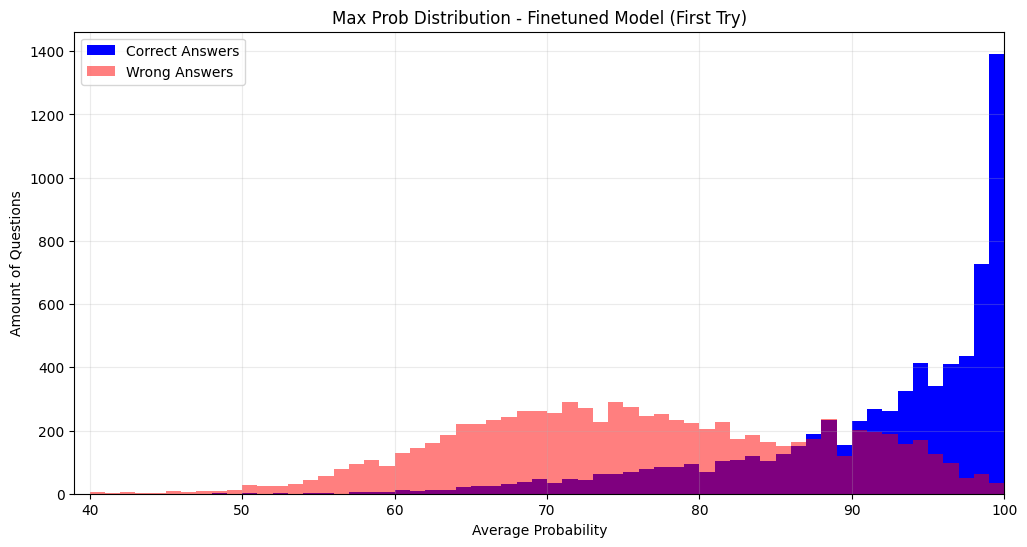

In [30]:
def plot_max_prob_histogram(
    frame: pd.DataFrame,
    try_name: str = "first",
    title: str = "Maximum Probability Distribution"
):
    prob_col = f"{try_name}_try_max_prob"
    correct_col = f"{try_name}_try_correct"
    
    if prob_col not in frame.columns or correct_col not in frame.columns:
        print(f"Columns {prob_col} or {correct_col} not found.")
        return

    # Get data and drop NaNs
    data = frame[[prob_col, correct_col]].copy()
    data[prob_col] = pd.to_numeric(data[prob_col], errors='coerce')
    data = data.dropna(subset=[prob_col])
    
    # Ensure 0-100 scale: if max value is <= 1.0, assume it's 0-1 and scale up
    if data[prob_col].max() <= 1.0:
        data[prob_col] *= 100.0
        
    # User requested averaging to integers -> Bins of width 1 centered on integers or just integer edges
    bins = np.arange(0, 102, 1)
    
    correct_mask = data[correct_col].astype(bool)
    probs_correct = data.loc[correct_mask, prob_col]
    probs_wrong = data.loc[~correct_mask, prob_col]

    plt.figure(figsize=(12, 6))
    
    # Plot histograms
    plt.hist(
        probs_correct,
        bins=bins,
        alpha=1.0,
        color='blue',
        label='Correct Answers'
    )
    plt.hist(
        probs_wrong,
        bins=bins,
        alpha=0.5,
        color='red',
        label='Wrong Answers'
    )
    
    plt.xlabel("Average Probability")
    plt.ylabel("Amount of Questions")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.25)
    plt.xlim(39, 100)
    plt.show()

# Show for finetuned model (First Try)
plot_max_prob_histogram(finetuned_single, title="Max Prob Distribution - Finetuned Model (First Try)")

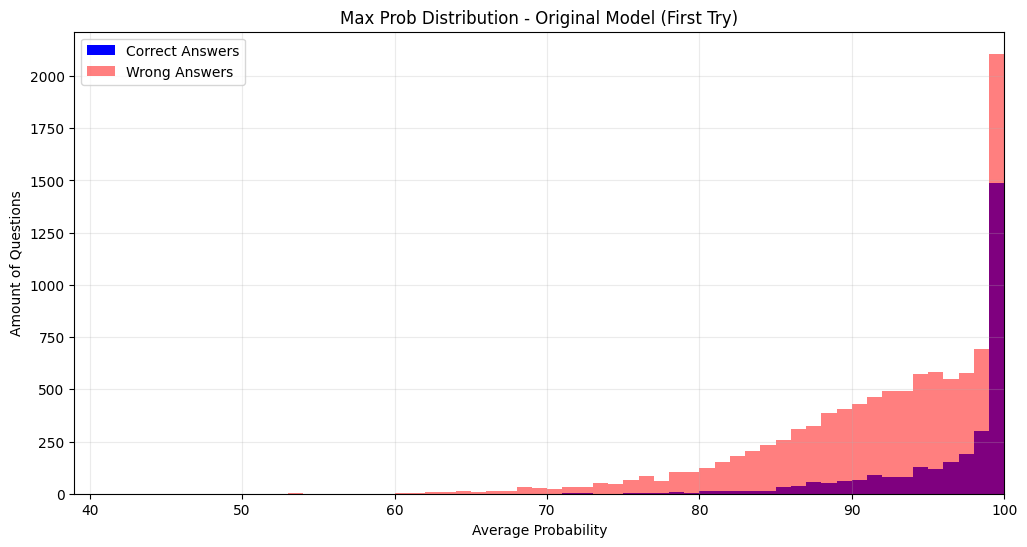

In [31]:
# Show for finetuned model (First Try)
plot_max_prob_histogram(before_single, title="Max Prob Distribution - Original Model (First Try)")

## A) Disentangle two effects of finetuning on conf-corr AUROC.
So the two effects of finetuning are:
1. It alters token probabilities for logprob methods or model thinking process for verbalized confidence
2. It changes the accuracy of the model which affects which examples are evaluated in AUROC as correct and which are evaluated as incorrect.


Right now if you see gains in AUROC after fine-tuning, it is an open question which of these two effects caused it. One way to test this is to do additional analysis experiment where you only retain examples where the label (correct / incorrect) didn't change. This way you contro for effect #2 and can see how much #1 matters.

# TODO: Create a filtered dataset of the before model and the finetuned model where only these questions are retained which answer didn't change. To this for both all question types (multi and single answer) and also for single answer questions. Again, plot the auroc and precision/recall curves, in similar fashion like before, where if the AUROC is below 0.5, the classifier is inversed.

Original rows: 24889
Rows with unchanged outcome: 14560 (58.5%)
Single-answer rows with unchanged outcome: 9201
Saved roc_curve_all_groups.png
Saved roc_curve_all_groups.png


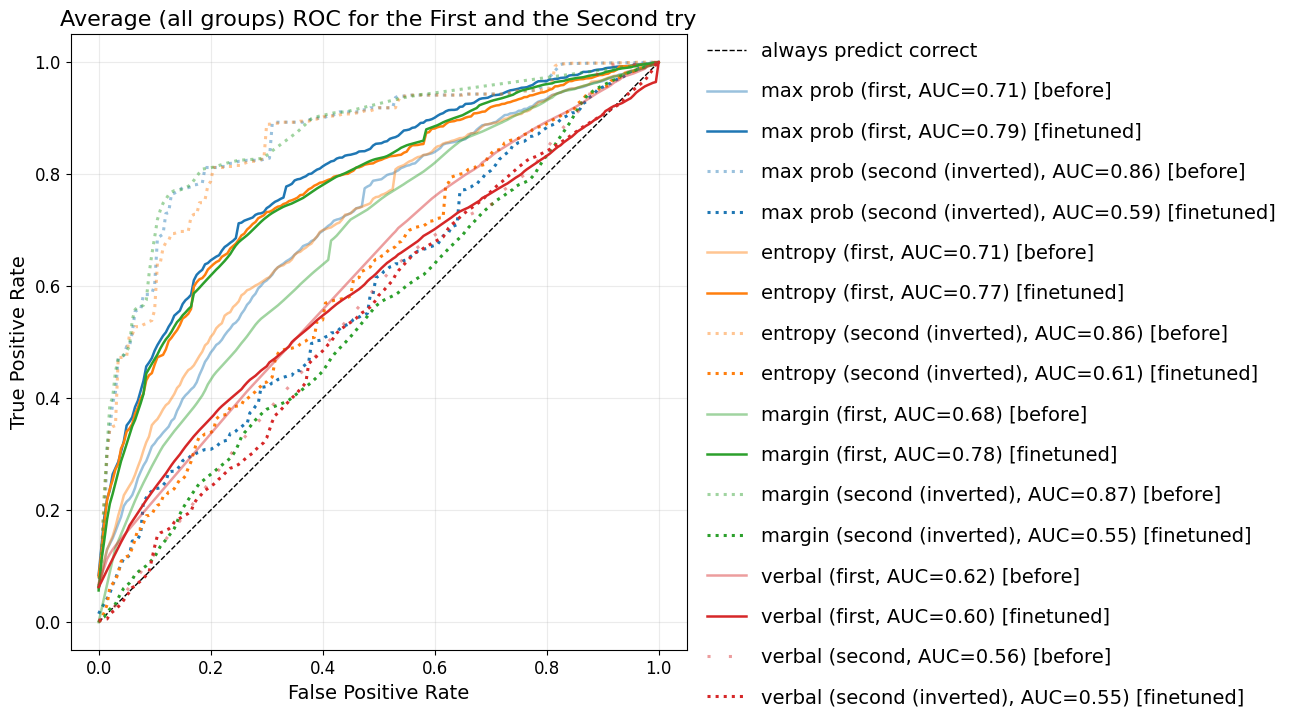

Saved pr_curve_all_groups.png


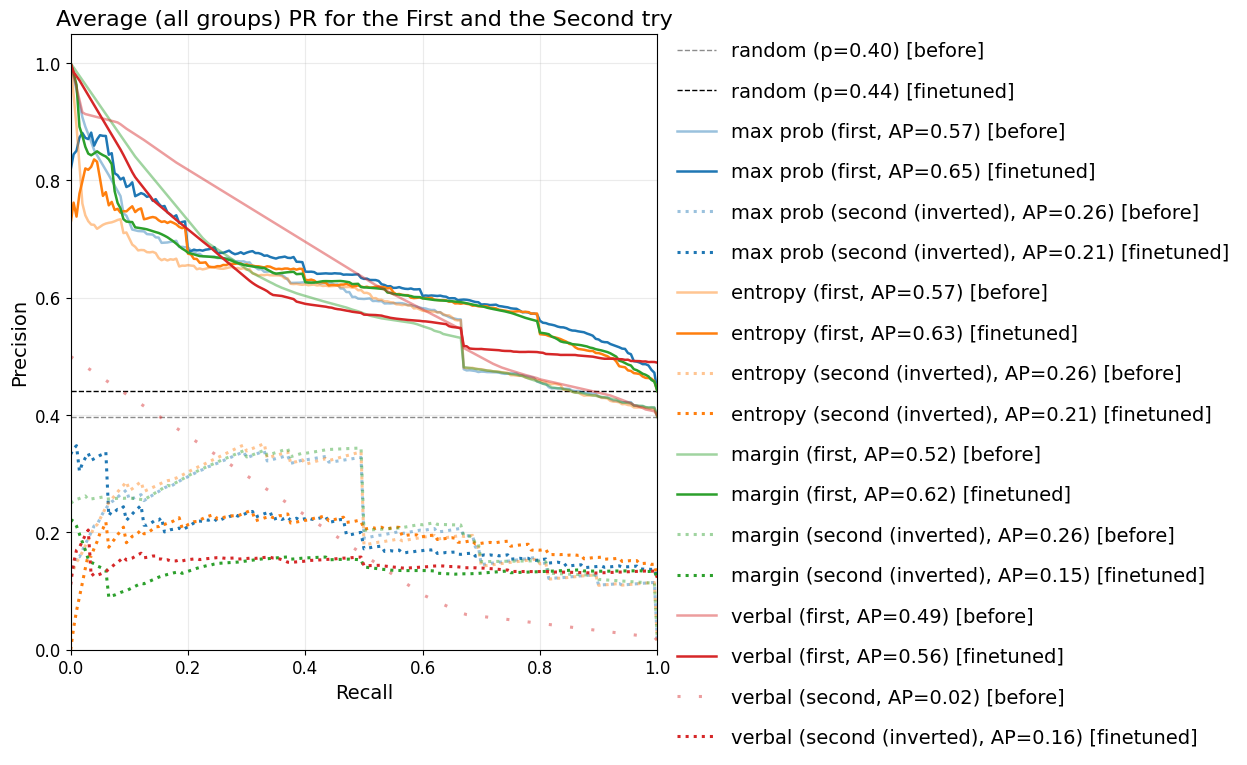

Saved roc_curve_single_answer.png


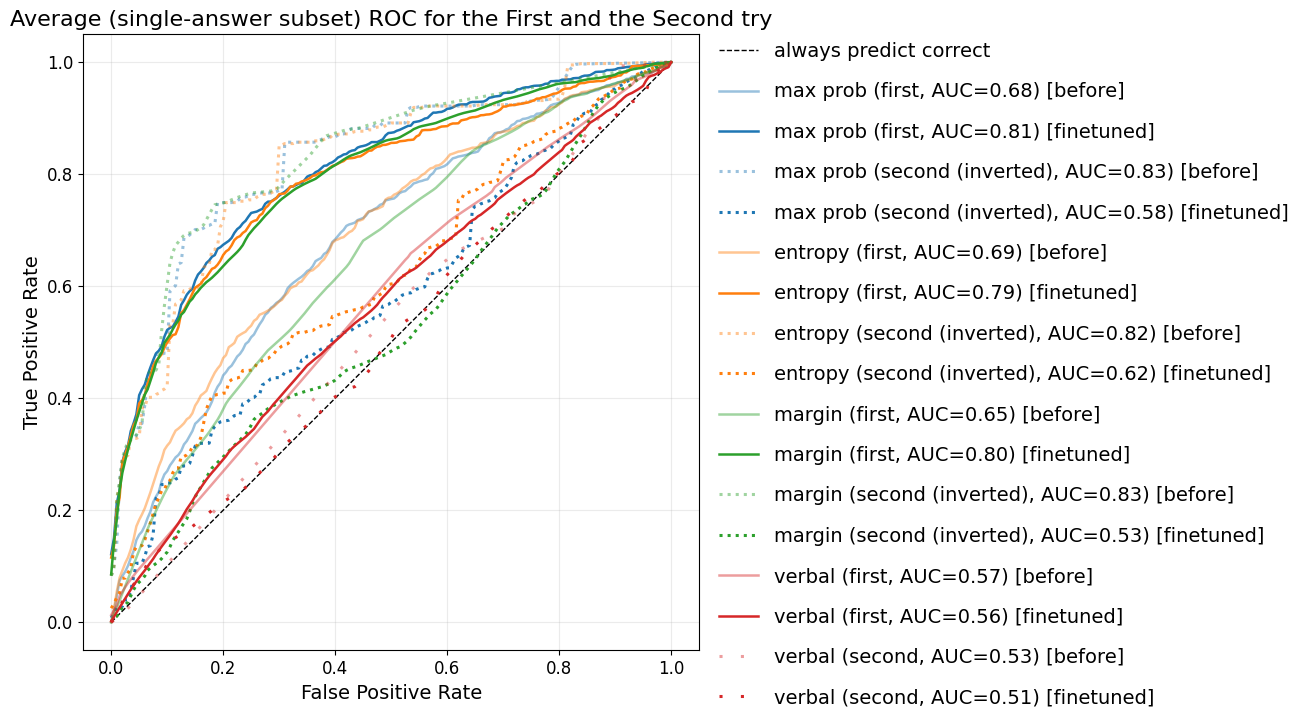

Saved pr_curve_single_answer.png


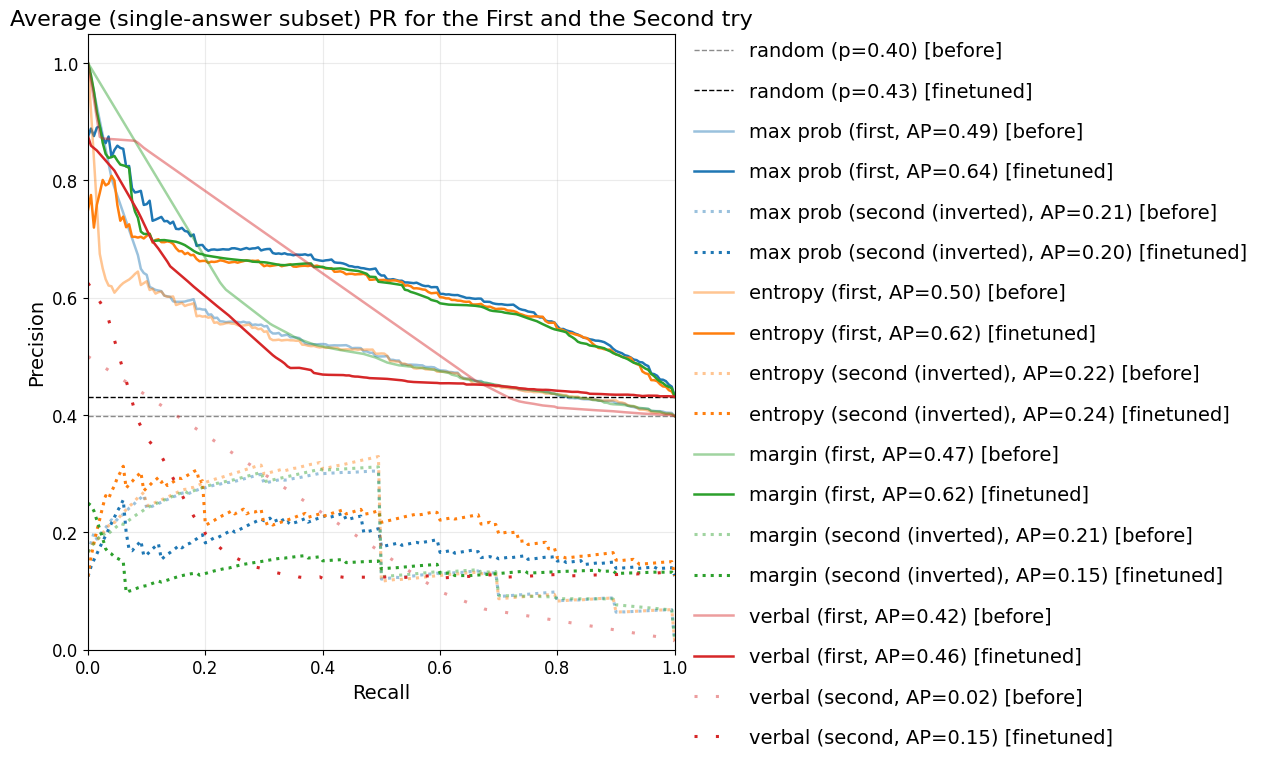

In [32]:
# Filter datasets to retain only examples where the outcome (correct/incorrect) didn't change
# We assume the dataframes are row-aligned by default.

if len(before_df) != len(finetuned_df):
    print(f"Warning: Length mismatch (Before: {len(before_df)}, Finetuned: {len(finetuned_df)})")
    # For safety, using intersection of indices if they differ
    common_idx = before_df.index.intersection(finetuned_df.index)
    b_temp = before_df.loc[common_idx]
    f_temp = finetuned_df.loc[common_idx]
else:
    b_temp = before_df
    f_temp = finetuned_df

# Identify rows where the label (first_try_correct) is identical
mask_outcome_unchanged = (b_temp["first_try_correct"] == f_temp["first_try_correct"])

# Create the filtered "All" datasets
before_same_all = b_temp[mask_outcome_unchanged].copy()
finetuned_same_all = f_temp[mask_outcome_unchanged].copy()

# Create the filtered "Single" datasets
# Applying the single-answer mask to the already filtered outcome datasets
mask_single_subset = single_answer_mask(before_same_all)
before_same_single = before_same_all[mask_single_subset].copy()
finetuned_same_single = finetuned_same_all[mask_single_subset].copy()

print(f"Original rows: {len(b_temp)}")
print(f"Rows with unchanged outcome: {len(before_same_all)} ({len(before_same_all)/len(b_temp):.1%})")
print(f"Single-answer rows with unchanged outcome: {len(before_same_single)}")

# Plot AUROC and PR curves for the filtered subsets
plot_average_panels_compare(
    before_same_all,
    before_same_single,
    finetuned_same_all,
    finetuned_same_single,
    fig_title_suffix=""
)

## B) Confidence distribution, calibration, and reliability diagram
Yet another, is that you can after all draw "reliability diagrams" and compute ECE just to see the distribution of confidence scores and their out-of-the-box calibration.

# TODO: Draw reliability diagrams 

Saved figure to reliability_diagram_.png


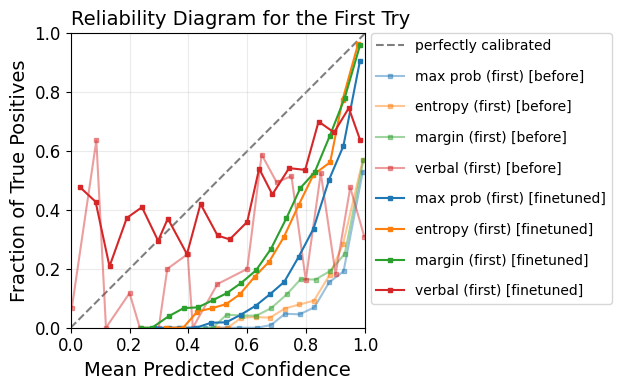

Saved figure to reliability_diagram_single_answer_questions.png


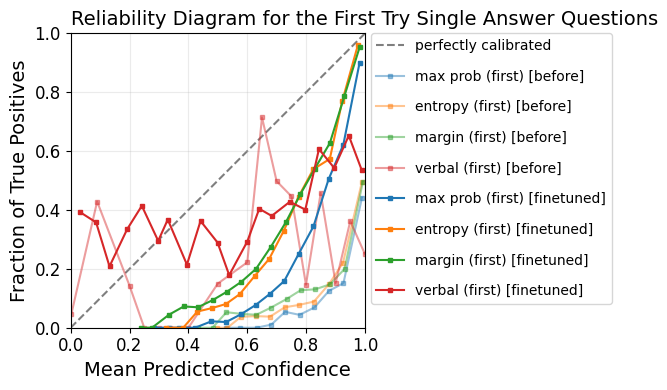

In [33]:
from sklearn.calibration import calibration_curve

def plot_combined_reliability(
    before_frame: pd.DataFrame,
    finetuned_frame: pd.DataFrame,
    dataset_title: str,
    n_bins: int = 20,
):
    # Width increased, and aspect ratio constraint removed below
    fig, ax = plt.subplots(figsize=(10, 4))
    
    # Diagonal perfect calibration line
    ax.plot([0, 1], [0, 1], "k--", label="perfectly calibrated", alpha=0.5, zorder=0)

    # Styles mimicking the AUROC function
    lw_first = 1.5
    
    # Define models to plot: (dataframe, label, base_alpha)
    models = [
        (before_frame, "before", 0.45),
        (finetuned_frame, "finetuned", 1.0)
    ]
    
    for frame, label_prefix, base_alpha in models:
        for metric in METRICS:
            color = METRIC_COLORS[metric]
            metric_label = METRIC_LABELS.get(metric, metric)
            
            # Only plot first try
            for try_name in ["first"]:
                score_col = _score_col(try_name, metric)
                label_col = _label_col(try_name)

                if score_col not in frame.columns or label_col not in frame.columns:
                    continue

                y_true = frame[label_col].to_numpy(dtype=int)
                raw_scores = _coerce_numeric(frame[score_col])
                
                # Filter NaNs
                mask = np.isfinite(raw_scores)
                y_true = y_true[mask]
                raw_scores = raw_scores[mask]
                
                if len(raw_scores) == 0:
                    continue

                # Note: Entropy is already 0-100 where 100 is high confidence
                scores = raw_scores.copy()
                
                # Normalize 0-100 scores to 0-1
                if np.max(scores) > 1.1:
                    scores = scores / 100.0
                scores = np.clip(scores, 0.0, 1.0)
                
                # Compute calibration curve
                prob_true, prob_pred = calibration_curve(y_true, scores, n_bins=n_bins, strategy='uniform')
                
                # Determine styling
                ls = "-"
                lw = lw_first
                alpha = base_alpha
                marker = "s"

                ax.plot(
                    prob_pred, 
                    prob_true, 
                    marker=marker, 
                    markersize=3,
                    linestyle=ls,
                    linewidth=lw, 
                    color=color,
                    alpha=alpha,
                    label=f"{metric_label} ({try_name}) [{label_prefix}]"
                )

    # Increase font sizes for labels and title
    ax.set_xlabel("Mean Predicted Confidence", fontsize=14)
    ax.set_ylabel("Fraction of True Positives", fontsize=14)
    
    # Increase tick label font size
    ax.tick_params(axis='both', which='major', labelsize=12)
    
    # Set title to the right to reduce left-side whitespace impact
    full_title = f"Reliability Diagram for the First Try {dataset_title}"
    if "-" in full_title:
        full_title = full_title.replace("-", "\n", 1)
    ax.set_title(full_title, loc="left", fontsize=14)
    
    # Place legend outside to avoid clutter, with increased spacing
    ax.legend(
        loc='upper left', 
        bbox_to_anchor=(1.02, 1), 
        borderaxespad=0, 
        fontsize='medium',
        labelspacing=1.2
    )
    
    ax.grid(True, alpha=0.25)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    
    # Removed aspect="equal" to allow the plot to be wider
    ax.set_aspect("equal", adjustable="box")
    
    plt.tight_layout()
    
    # Save the figure with high resolution
    clean_title = dataset_title.replace(" ", "_").replace("(", "").replace(")", "").lower()
    save_path = f"reliability_diagram_{clean_title}.png"
    plt.savefig(save_path, dpi=900, bbox_inches="tight")
    print(f"Saved figure to {save_path}")

    plt.show()

# Run comparisons
plot_combined_reliability(before_df, finetuned_df, "")
plot_combined_reliability(before_single, finetuned_single, "Single Answer Questions")

### Reliability graph but only these questions are retained to which both the before and finetuned model answered correctly or retained, e.g. the model's correctness didn't change

Saved figure to reliability_diagram_-all_question_types_outcome_unchanged.png


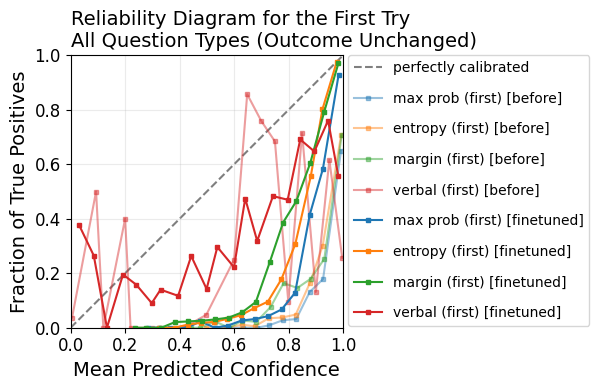

Saved figure to reliability_diagram_-single_answer_questions_outcome_unchanged.png


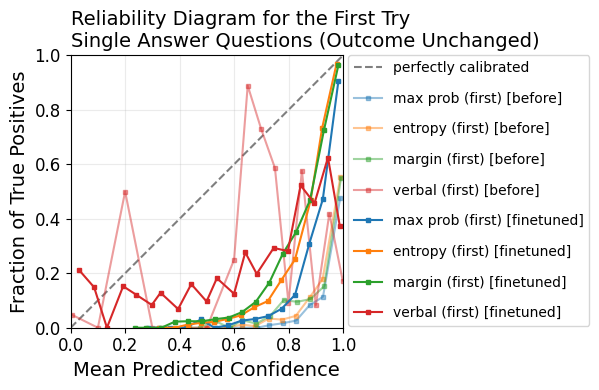

In [37]:
# Plot reliability diagrams for the subset where outcome didn't change
# Using dataframes created in step A: before_same_all, finetuned_same_all, etc.

plot_combined_reliability(
    before_same_all, 
    finetuned_same_all, 
    "-All Question Types (Outcome Unchanged)"
)

plot_combined_reliability(
    before_same_single, 
    finetuned_same_single, 
    "-Single Answer Questions (Outcome Unchanged)"
)

# TODO: Compute ECE

Saved ece_comparison_all_questions.png


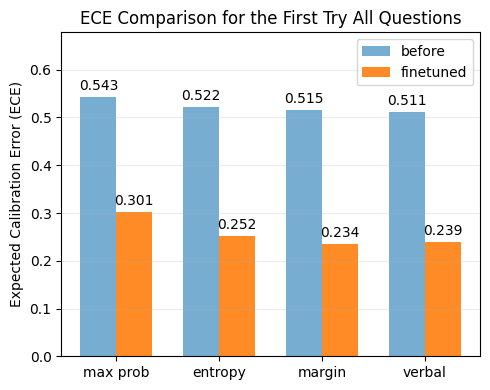

Saved ece_comparison_single_answer_questions.png


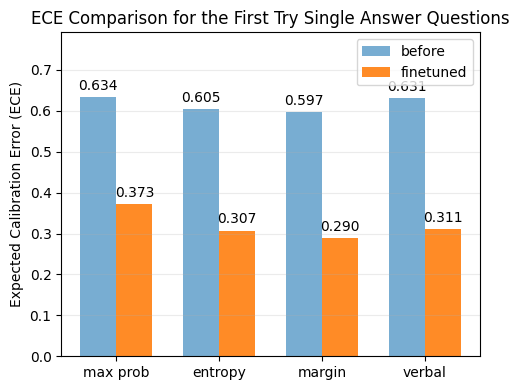

In [35]:
def calculate_ece(labels: np.ndarray, probs: np.ndarray, n_bins: int = 20) -> float:
    """Calculates Expected Calibration Error."""
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    
    ece = 0.0
    total_samples = len(probs)
    
    for i in range(n_bins):
        lower = bin_boundaries[i]
        upper = bin_boundaries[i+1]
        
        # Include upper bound for last bin
        if i == n_bins - 1:
            mask = (probs >= lower) & (probs <= upper)
        else:
            mask = (probs >= lower) & (probs < upper)
            
        if not np.any(mask):
            continue
            
        # Accuracy in bin
        acc = labels[mask].mean()
        # Average confidence in bin
        conf = probs[mask].mean()
        
        count = np.sum(mask)
        ece += (count / total_samples) * np.abs(acc - conf)
        
    return ece

def plot_ece_comparison(
    before_frame: pd.DataFrame,
    finetuned_frame: pd.DataFrame,
    title: str
):
    results = []
    
    # Calculate ECE for each metric and model
    for metric in METRICS:
        for model_name, frame in [("Before", before_frame), ("Finetuned", finetuned_frame)]:
            # Focus on first try only as requested
            try_name = "first"
            score_col = _score_col(try_name, metric)
            label_col = _label_col(try_name)
            
            if score_col not in frame.columns or label_col not in frame.columns:
                continue
                
            y_true = frame[label_col].to_numpy(dtype=int)
            raw_scores = _coerce_numeric(frame[score_col])
            
            # Filter NaNs
            mask = np.isfinite(raw_scores)
            y_true = y_true[mask]
            raw_scores = raw_scores[mask]
            
            if len(raw_scores) == 0:
                continue

            # Scores are 0-100, normalize to 0-1
            # Note: Entropy is treated as 0-100 confidence (100=high)
            scores = raw_scores.copy()
            if np.max(scores) > 1.1:
                scores = scores / 100.0
            scores = np.clip(scores, 0.0, 1.0)
            
            ece = calculate_ece(y_true, scores)
            results.append({
                "Metric": METRIC_LABELS.get(metric, metric),
                "Model": model_name,
                "ECE": ece
            })
            
    df_res = pd.DataFrame(results)
    
    if df_res.empty:
        print(f"No valid ECE data for {title}")
        return

    # Plot
    fig, ax = plt.subplots(figsize=(5, 4))
    
    # Pivot for plotting
    pivot = df_res.pivot(index="Metric", columns="Model", values="ECE")
    
    # Bar plot setup
    x = np.arange(len(pivot.index))
    width = 0.35
    
    # Ensure order matches METRICS if possible
    # We need to map METRICS to their labels for reindexing
    metrics_labels_ordered = [METRIC_LABELS.get(m, m) for m in METRICS]
    metrics_present = [m for m in metrics_labels_ordered if m in pivot.index]
    pivot = pivot.reindex(metrics_present)
    
    # Plot bars
    if "Before" in pivot.columns:
        rects1 = ax.bar(x - width/2, pivot["Before"], width, label='before', alpha=0.6, color='tab:blue')
        ax.bar_label(rects1, fmt='%.3f', padding=3)
        
    if "Finetuned" in pivot.columns:
        rects2 = ax.bar(x + width/2, pivot["Finetuned"], width, label='finetuned', alpha=0.9, color='tab:orange')
        ax.bar_label(rects2, fmt='%.3f', padding=3)
    
    ax.set_ylabel('Expected Calibration Error (ECE)')
    ax.set_title(f'ECE Comparison for the First Try {title}')
    ax.set_xticks(x)
    ax.set_xticklabels(pivot.index)
    
    # Dynamic Y limits
    max_val = df_res["ECE"].max()
    ax.set_ylim(0, max_val * 1.25)
    
    ax.legend(loc='upper right')
    ax.grid(True, axis='y', alpha=0.25)
    
    plt.tight_layout()
    
    # Save figure
    clean_title = title.replace(" ", "_").replace("(", "").replace(")", "").lower()
    save_path = f"ece_comparison_{clean_title}.png"
    plt.savefig(save_path, dpi=900, bbox_inches="tight")
    print(f"Saved {save_path}")
    
    plt.show()

# Run for both scopes
plot_ece_comparison(before_df, finetuned_df, "All Questions")
plot_ece_comparison(before_single, finetuned_single, "Single Answer Questions")

### ECE graph but only these questions are retained to which both the before and finetuned model answered correctly or retained, e.g. the model's correctness didn't change

Saved ece_comparison_.png


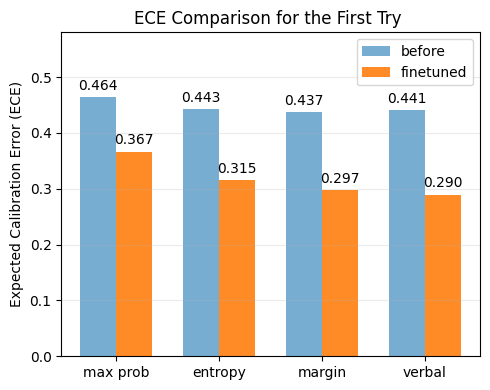

Saved ece_comparison_single_answer_questions_outcome_unchanged.png


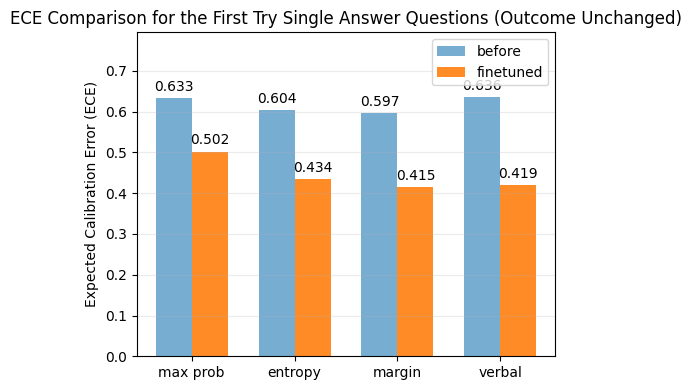

In [36]:
# Plot ECE comparison for the subset where outcome didn't change
plot_ece_comparison(
    before_same_all, 
    finetuned_same_all, 
    ""
)

plot_ece_comparison(
    before_same_single, 
    finetuned_same_single, 
    "Single Answer Questions (Outcome Unchanged)"
)